Checking out how to work with the ifbo repo

In [1]:
import torch
import numpy as np
import ifbo
from ifbo import Curve, PredictionResult
from ifbo.priors.ftpfn_prior import DatasetPrior

import matplotlib.pyplot as plt


N_LC_PARAMETERS = 23 # Number of parameters for the learning curve basis and their weights


/home/ruhkopf/anaconda3/envs/eft-pfn/lib/python3.11/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


# How to sample the Prior and evaluate curves off of it (on any fidelity level). & Dirichlet prior
we basically have the "ground truth" curves with the sampled hyperparameters here
--> and we get a functional that we can evaluate for the hp on any fidelity level, as often as we like.
The partial curves are collected off of this in `get_batch` using a dirichlet prior, that samples a randomly ordered index vector.
This index vector corresponds to a hyperparameter configuration. Then in a "cum_sum" fashion, from left to right, the index vector is read and allocates budgets. i.e. \[3, 1, 3, 4\] would result in config 1 and 4 being allocated 1 budget increment and config 3 being allocated 2 budget increments. Lastly, the `single_eval_pos` will determine for the seq_len (sequence length of the transformer) where the split between train context and query tokens lies; i.e.
\[3, 1, 3, 4, 3\] with `single_eval_pos=3` would result in config 1 having 2 context budget tokens in the context and config 3 having 2 budget tokens in the context. config 4 will be queried and config 3 will be queried at a budget of 3 (because the curve is continued)

All of which can now be evaluated for `y_train` and `y_test` with the `curve_func` function.

In [39]:

n_hyperparameter_dims = 3
dataset = DatasetPrior(num_params=n_hyperparameter_dims, num_outputs=N_LC_PARAMETERS)
n_hyperparameters = 2
configs = np.random.uniform(
    size=(n_hyperparameters, 3))  # 5 configurations with 3 parameters each

curve_func = dataset.curves_for_configs(configs)
# @Tim Notice, how the curve function here allows to evaluate the entire basket
# at any point of interest.
x = np.linspace(0, 1, 100)

try:
    curve_func(x, 4)
except IndexError:
    print("IndexError: The index is out of bounds for the number of configurations; only for the configs passed to "
          "dataset.curves_for_configs, we can query them by index")


curve_func

IndexError: The index is out of bounds for the number of configurations; only for the configs passed to dataset.curves_for_configs, we can query them by index


<function ifbo.priors.ftpfn_prior.DatasetPrior.curves_for_configs.<locals>.foo(x_: numpy.ndarray, cid: int = 0) -> numpy.ndarray>

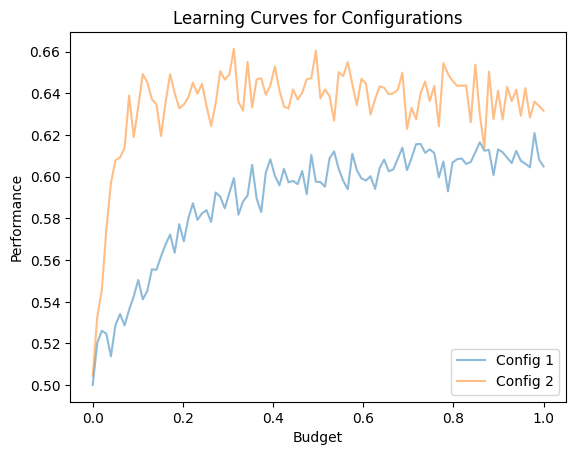

In [36]:
# Now we can use the curve_func to evaluate any of the hps that we sampled
for i, config in enumerate(configs):
    y = curve_func(x, i)
    plt.plot(x, y, label=f'Config {i + 1}', alpha=0.5)

plt.xlabel('Budget')
plt.ylabel('Performance')
plt.title('Learning Curves for Configurations')
plt.legend()
plt.show()

# Instantiate the FT-PFN model and fwd with it

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ifbo.surrogate.FTPFN(version="0.0.1", device=device)

print(
    f"Using a Transformer with {sum(p.numel() for p in model.parameters()) / 1000 / 1000:.{2}f} M parameters"
)

context = [
    Curve(hyperparameters=torch.tensor([0.2, 0.1, 0.5]), t=torch.tensor([0.1, 0.2, 0.3]),
          y=torch.tensor([0.1, 0.15, 0.3])),
    Curve(hyperparameters=torch.tensor([0.2, 0.3, 0.25]), t=torch.tensor([0.1, 0.2, 0.3, 0.4]),
          y=torch.tensor([0.2, 0.5, 0.6, 0.75])),
]

query = [  # notice, that Curve is used, but y is not provided
    Curve(hyperparameters=torch.tensor([0.2, 0.1, 0.5]),
          t=torch.tensor([0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1])),
    Curve(hyperparameters=torch.tensor([0.2, 0.3, 0.25]),
          t=torch.tensor([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])),
    Curve(hyperparameters=torch.tensor([0.8, 0.2, 0.6]),
          t=torch.tensor([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])),
]

predictions: list[PredictionResult] = model.predict(context=context, query=query)



Using a Transformer with 14.69 M parameters


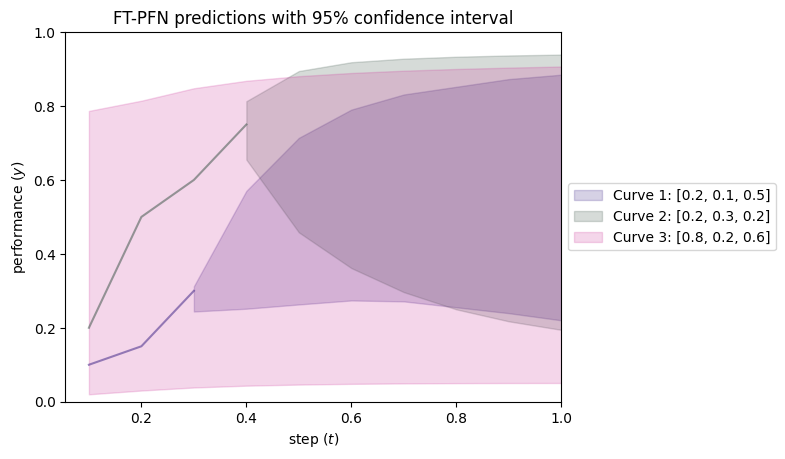

In [5]:
for curve in context:
    plt.plot(curve.t, curve.y, color=curve.hyperparameters.numpy().tolist() + [0.5])

for i, (curve, pred) in enumerate(zip(query, predictions)):
    c = curve.hyperparameters.numpy().tolist() + [0.2]
    y025, y975 = pred.quantile(0.025).cpu(), pred.quantile(0.975).cpu()
    label = f"Curve {i + 1}: " + str(
        [round(_, 1) for _ in curve.hyperparameters.numpy().tolist()])
    torch.round(curve.hyperparameters, decimals=1).tolist()
    plt.fill_between(curve.t, y025, y975, color=c, label=label)

plt.ylim(0, 1), plt.xlim(None, 1)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="")
plt.xlabel("step ($t$)")
plt.ylabel("performance ($y$)")
plt.title("FT-PFN predictions with 95% confidence interval")
plt.show()

 # Sample incomplete curves with (context and query split)


@TIM Notice This is the amount of budget spent (epochs) across the curves
basically, the total amount of budget spent. The dirichlet prior is already in their and
ensures, that we check the nll for any budget allocation -- i.e. explorative and
exploitative ones. So we will need to do repeated samples here for a fixed single_eval_pos,
collect the nll loss / calibration error and then check for increasing amounts of budget /
context!

In [6]:
single_eval_pos = 700  # number of observations in the context (< seq_len).

# TODO: investigate what part is the Dirichlet exactly!
batch = ifbo.priors.ftpfn_prior.get_batch(
    batch_size=1,
    seq_len=1000,  # maximum number of observations per task for training. Default: 1000.
    num_features=12,
    # sample the dimension of HPs with Uniform(1, num_features-1). Default: 12.
    single_eval_pos=single_eval_pos
)

batch.__dict__.keys()
# all of these are of [batch, seq_len, specific dimensions]
batch.x.shape
batch.y.shape
batch.target_y.shape

if batch.x.shape[1] == 1:
    # note: target_y is just a copy of y
    all(batch.target_y == batch.y)

context, query = ifbo.utils.detokenize(batch, context_size=single_eval_pos, device=device)

predictions: list[PredictionResult] = model.predict(context=context, query=query)


In [ ]:
for curve in context:
        plt.plot(curve.t, curve.y, color=curve.hyperparameters.numpy().tolist() + [0.5])

for i, (curve, pred) in enumerate(zip(query, predictions[:10])):
    c = curve.hyperparameters.numpy().tolist() + [0.2]
    y025, y975 = pred.quantile(0.025).cpu(), pred.quantile(0.975).cpu()
    label = f"Curve {i + 1}: " + str(
        [round(_, 1) for _ in curve.hyperparameters.numpy().tolist()])
    torch.round(curve.hyperparameters, decimals=1).tolist()
    plt.fill_between(curve.t, y025, y975, color=c, label=label)

plt.ylim(0, 1), plt.xlim(None, 1)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="")
plt.xlabel("step ($t$)")
plt.ylabel("performance ($y$)")
plt.title("FT-PFN predictions with 95% confidence interval")
plt.show()

# Collect the NLL loss for the test datapoints
Single NLL collection via `FTPFN.model.criterion`, which is of type `BarDistribution`

In [14]:
# fixme: how to measure the nll loss? check ifbo.train.py & bar_distribution.py, because
#  bar_distribution is the type of criterion used in the loss
assert len(query) == len(predictions), 'len(query) != len(predictions)'
# nll = [prediction.likelihood().cpu() for prediction in predictions]

b = batch
# fixme: batch wise evaluation does not work with model.forward??? --> squeeze
logits = model.forward(
    x_train=b.x[:single_eval_pos].squeeze(1),
    y_train=b.y[:single_eval_pos].squeeze(1),
    x_test=b.x[single_eval_pos:].squeeze(1),
)

nll = sum(
    model.model.criterion(
        #  shapes are correct here though
        logits,
        b.y[single_eval_pos:],
    )
)


probably the easier way is to go via the `PredictionResult` object, which computes the likelihood for each of the query points based on the `BarDistributiuon` and the logits, but does this in an akward way; it basically first aggregates the query points into the curves and only then per curve computes the likelihood contributions. which is more inefficient then doing it directly with the fwd pass on a batch.

In [ ]:
len(query), len(predictions)
nll = [prediction.likelihood(q.y).cpu() for prediction, q in zip(predictions, query)]
nll  # for each curve's query points, we will get the individual nll loss contributions, but sorted by curve -- unevenly sized tensors
nll = sum([sum(-prediction.likelihood(q.y).cpu()) for prediction, q in zip(predictions, query)])
nll

Trying to fix the batchwise evaluation with a fwd pass, by adding a batch_forward method

In [ ]:

# Try to fix the batch issue in model.forward for nll evaluation:
class ModifiedFTPFN(ifbo.surrogate.FTPFN):
    def batch_forward(
            self,
            x_train: torch.Tensor,
            y_train: torch.Tensor,
            x_test: torch.Tensor
    ) -> torch.Tensor:
        """Forward pass through the model.

        Args:
            x_train (torch.Tensor): context points, shape (batch_size x n_context x features)
            y_train (torch.Tensor): context values, shape (batch_size x n_context)
            x_test (torch.Tensor): query points, shape (batch_size x n_query x features)

        Returns:
            torch.Tensor: logits for query points, shape (batch_size x n_query)
        """
        self._check_input(x_train, y_train, x_test)
        batch_size = x_train.shape[0]

        # Handle ID modifications for batched inputs
        if x_train.shape[1] == 0:
            x_test[..., 0] = 0
        else:
            # Add 1 to IDs if min ID is 0 (batch-wise operation)
            zero_mask = x_train[..., 0].min(dim=1).values == 0
            x_train[zero_mask, :, 0] += 1
            x_test[zero_mask, :, 0] += 1

            # Create batch-specific masks for ID validation
            for i in range(batch_size):
                valid_ids = x_train[i, :, 0]
                x_test[i, :, 0] = torch.where(
                    torch.isin(x_test[i, :, 0], valid_ids),
                    x_test[i, :, 0],
                    torch.zeros_like(x_test[i, :, 0])
                )

        single_eval_pos = x_train.shape[1]
        query_batch_size = 2000  # Per-batch elements to process
        n_batches = (x_test.shape[1] + query_batch_size - 1) // query_batch_size

        results = []
        for i in range(n_batches):
            start = i * query_batch_size
            end = min((i + 1) * query_batch_size, x_test.shape[1])

            # Concatenate context and query points along sequence dimension
            x_batch = torch.cat([
                x_train,  # (batch_size, n_context, features)
                x_test[:, start:end, :]  # (batch_size, n_queries, features)
            ], dim=1).unsqueeze(2)  # Add dummy dimension if needed by your model

            y_batch = y_train.unsqueeze(2)  # (batch_size, n_context, 1)

            # Process through model (adjust based on actual model expectations)
            result = self.model(
                (x_batch, y_batch),
                single_eval_pos=single_eval_pos
            )
            results.append(result)

        return torch.cat(results, dim=1)

model = ModifiedFTPFN(version="0.0.1", device=device)

single_eval_pos=700
batch = ifbo.priors.ftpfn_prior.get_batch(
    batch_size=2,
    seq_len=1000,  # maximum number of observations per task for training. Default: 1000.
    num_features=12,
    # sample the dimension of HPs with Uniform(1, num_features-1). Default: 12.
    single_eval_pos=single_eval_pos
)

# normalize x
x = batch.x
x = (x-x.min())/(x.max()-x.min())

x_train = x[:single_eval_pos].permute(1,0,2)
y_train = batch.y.permute(1,0)
x_test = x[single_eval_pos:].permute(1,0,2)


logits = model.batch_forward(x_train=x_train, y_train=y_train, x_test=x_test)

# Collect quantiles for a calibration:
if we use the `PredictionResult` object, we can collect the quantiles for the calibration in the same (inefficient) way as the likelihood

In [34]:
predictions: list[PredictionResult] = model.predict(context=context, query=query)
median = [prediction.quantile(0.5).cpu() for prediction in predictions]
median

[tensor([0.4784, 0.4807, 0.4836, 0.4767, 0.4790, 0.4811, 0.4803, 0.4830, 0.4839,
         0.4823, 0.4819, 0.4815, 0.4833, 0.4773, 0.4779, 0.4752, 0.4794, 0.4759]),
 tensor([0.3408, 0.3575, 0.3589, 0.3530, 0.3439, 0.3580, 0.3488, 0.3564, 0.3524,
         0.3553, 0.3425, 0.3399, 0.3495, 0.3417, 0.3510, 0.3584, 0.3432, 0.3481]),
 tensor([0.4301, 0.4257, 0.4299, 0.4270, 0.4294, 0.4301, 0.4296, 0.4298, 0.4300,
         0.4276, 0.4292, 0.4285, 0.4301, 0.4288, 0.4250, 0.4281]),
 tensor([0.3668, 0.3662, 0.3685, 0.3679, 0.3674]),
 tensor([0.3323, 0.3142, 0.3188, 0.3229, 0.3099, 0.3297, 0.3326, 0.3170]),
 tensor([0.4880, 0.4846, 0.4856, 0.4685, 0.4819, 0.4806, 0.4860, 0.4757, 0.4724,
         0.4864, 0.4883]),
 tensor([0.4071, 0.4114, 0.4131, 0.4143, 0.4147, 0.4123, 0.4100, 0.4096, 0.4105,
         0.4135, 0.4086, 0.4127, 0.4091, 0.4076]),
 tensor([0.4237, 0.4238, 0.4239]),
 tensor([0.4189, 0.3959, 0.4181, 0.4168, 0.4177, 0.4107, 0.4116, 0.4050, 0.4192,
         0.4097, 0.4155, 0.4191, 0.3811, 0

In [40]:
[prediction.quantile(0.05).cpu() for prediction in predictions]

[tensor([0.4665, 0.4667, 0.4636, 0.4656, 0.4667, 0.4666, 0.4668, 0.4647, 0.4629,
         0.4657, 0.4661, 0.4663, 0.4642, 0.4660, 0.4663, 0.4646, 0.4668, 0.4651]),
 tensor([0.3310, 0.3474, 0.3489, 0.3432, 0.3342, 0.3479, 0.3394, 0.3464, 0.3426,
         0.3453, 0.3327, 0.3302, 0.3401, 0.3319, 0.3414, 0.3484, 0.3334, 0.3386]),
 tensor([0.4128, 0.4139, 0.4145, 0.4149, 0.4154, 0.4134, 0.4152, 0.4149, 0.4140,
         0.4152, 0.4156, 0.4156, 0.4120, 0.4156, 0.4134, 0.4154]),
 tensor([0.3569, 0.3562, 0.3586, 0.3580, 0.3574]),
 tensor([0.3225, 0.3045, 0.3093, 0.3133, 0.3001, 0.3201, 0.3228, 0.3074]),
 tensor([0.4649, 0.4684, 0.4679, 0.4584, 0.4683, 0.4678, 0.4676, 0.4645, 0.4618,
         0.4672, 0.4641]),
 tensor([0.3973, 0.4011, 0.4026, 0.4037, 0.4040, 0.4019, 0.3999, 0.3995, 0.4003,
         0.4030, 0.3987, 0.4023, 0.3991, 0.3978]),
 tensor([0.4111, 0.4108, 0.4105]),
 tensor([0.4034, 0.3830, 0.4036, 0.4030, 0.4035, 0.3976, 0.3985, 0.3917, 0.4027,
         0.3966, 0.4022, 0.4031, 0.3684, 0

In [41]:
[prediction.quantile(0.95).cpu() for prediction in predictions]

[tensor([0.4889, 0.4928, 0.4995, 0.4867, 0.4897, 0.4936, 0.4920, 0.4978, 0.5003,
         0.4961, 0.4953, 0.4944, 0.4986, 0.4875, 0.4882, 0.4849, 0.4905, 0.4858]),
 tensor([0.3500, 0.3667, 0.3683, 0.3624, 0.3533, 0.3672, 0.3585, 0.3657, 0.3618,
         0.3646, 0.3517, 0.3492, 0.3592, 0.3509, 0.3606, 0.3677, 0.3525, 0.3578]),
 tensor([0.4448, 0.4370, 0.4436, 0.4386, 0.4422, 0.4444, 0.4427, 0.4431, 0.4439,
         0.4393, 0.4417, 0.4406, 0.4451, 0.4412, 0.4360, 0.4399]),
 tensor([0.3766, 0.3760, 0.3783, 0.3778, 0.3772]),
 tensor([0.3421, 0.3237, 0.3282, 0.3323, 0.3190, 0.3393, 0.3424, 0.3264]),
 tensor([0.5067, 0.4993, 0.5012, 0.4783, 0.4943, 0.4924, 0.5022, 0.4863, 0.4827,
         0.5031, 0.5076]),
 tensor([0.4165, 0.4209, 0.4227, 0.4241, 0.4246, 0.4218, 0.4194, 0.4189, 0.4199,
         0.4231, 0.4180, 0.4222, 0.4185, 0.4169]),
 tensor([0.4353, 0.4356, 0.4359]),
 tensor([0.4324, 0.4091, 0.4309, 0.4293, 0.4304, 0.4230, 0.4239, 0.4179, 0.4332,
         0.4221, 0.4279, 0.4328, 0.3938, 0